# Visualisation

In [28]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../cleaned_merged_dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [5]:
df

,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,class,P-PDG_is_missing,gas_lift_active
0,2017-02-01 02:02:07,-999.0,10092110.0,119.094400,1609800.0,84.59782,1564147.0,0.0,0.0,1.0,1
1,2017-02-01 02:02:08,-999.0,10092000.0,119.094400,1618206.0,84.58997,1564148.0,0.0,0.0,1.0,1
2,2017-02-01 02:02:09,-999.0,10091890.0,119.094400,1626612.0,84.58213,1564148.0,0.0,0.0,1.0,1
3,2017-02-01 02:02:10,-999.0,10091780.0,119.094400,1635018.0,84.57429,1564148.0,0.0,0.0,1.0,1
4,2017-02-01 02:02:11,-999.0,10091670.0,119.094400,1643424.0,84.56644,1564148.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
43404279,2018-05-19 19:01:05,33586320.0,28076270.0,3.253794,4002285.0,37.74498,0.0,0.0,108.0,0.0,1
43404280,2018-05-19 19:01:06,33586440.0,28076420.0,3.253723,4002285.0,38.21421,0.0,0.0,108.0,0.0,1
43404281,2018-05-19 19:01:07,33586900.0,28076490.0,3.253835,4002278.0,38.75061,0.0,0.0,108.0,0.0,1
43404282,2018-05-19 19:01:08,33586480.0,28076560.0,3.253942,4002255.0,39.31084,0.0,0.0,108.0,0.0,1


<h1>30-Minute Temporal Trends per Day</h1>
By resampling the data to 30-minute intervals, we smooth out high-frequency noise and focus on the overall movement of temperatures and pressures across different days. The subplots below show the grouped sensors (Temp, Pressure, and Flow) for specific dates.

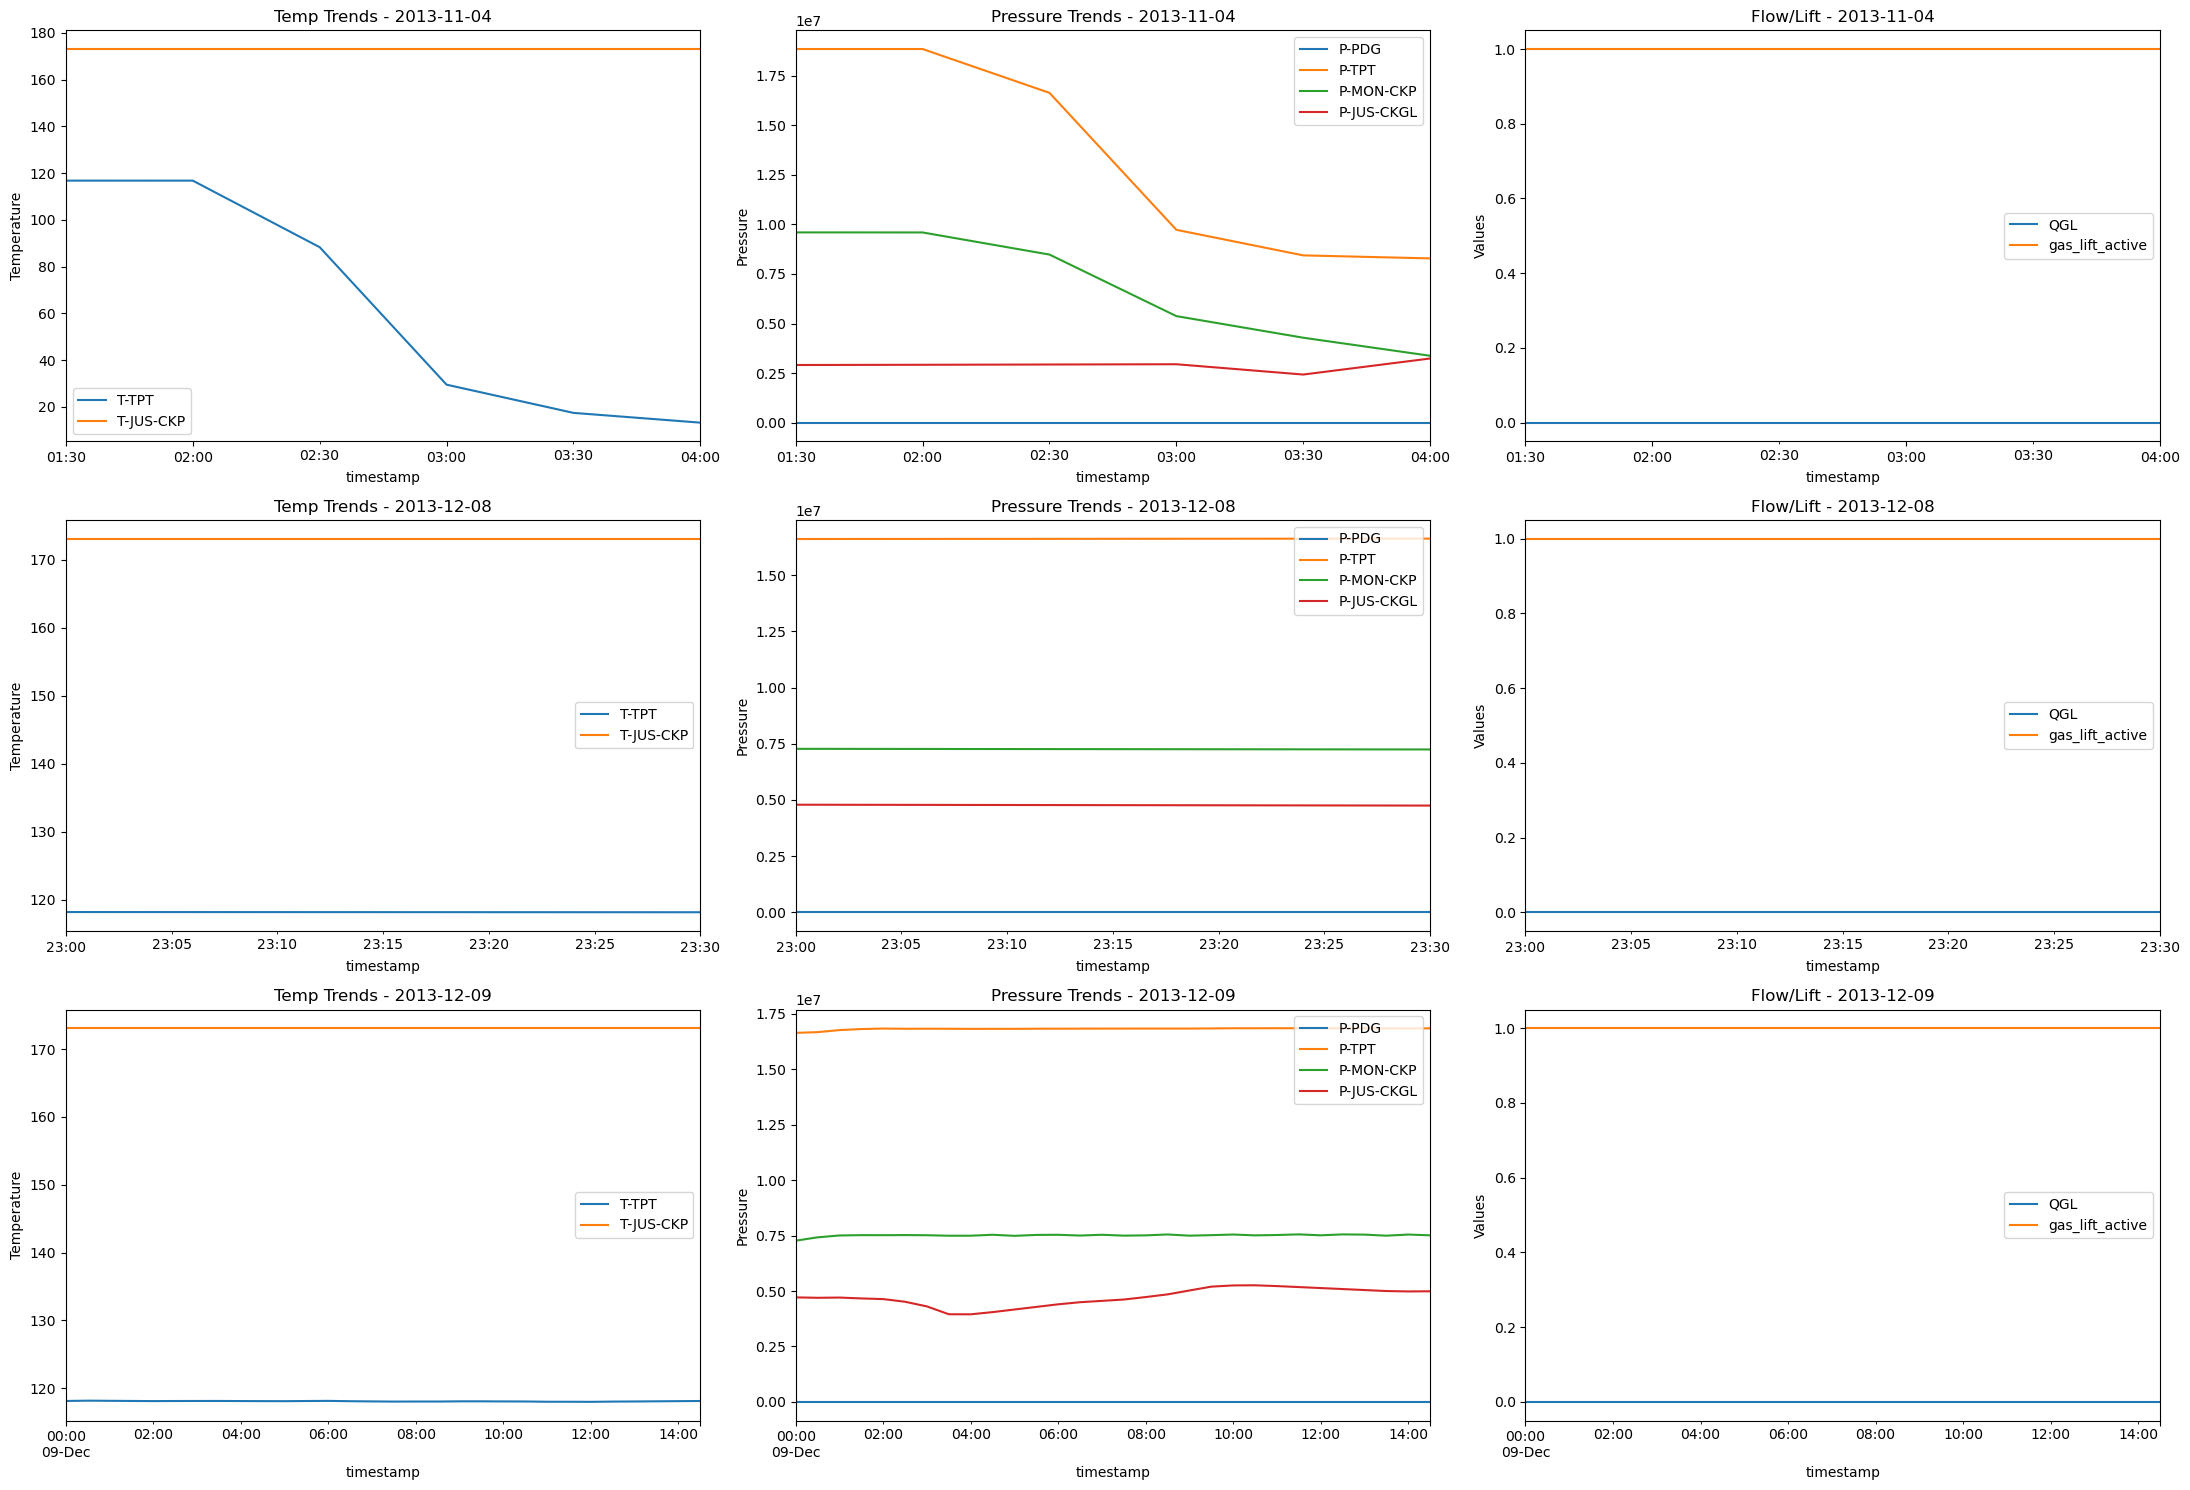

In [5]:
df = df.sort_values('timestamp')

# Column Groups
temp_cols = ['T-TPT', 'T-JUS-CKP']
press_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']
flow_cols = ['QGL', 'gas_lift_active']

# Select sample dates for visualization
unique_dates = df['timestamp'].dt.date.unique()
sample_dates = unique_dates[:10]  # Example: first 3 unique days

fig, axes = plt.subplots(nrows=len(sample_dates), ncols=3, figsize=(22, 5 * len(sample_dates)))

for i, date in enumerate(sample_dates):
    day_data = df[df['timestamp'].dt.date == date]
    # Resample to 30-minute mean trend
    day_resampled = day_data.set_index('timestamp').resample('30min').mean()
    
    # Temperature Plot
    day_resampled[temp_cols].plot(ax=axes[i, 0], title=f"Temp Trends - {date}")
    axes[i, 0].set_ylabel("Temperature")
    
    # Pressure Plot
    day_resampled[press_cols].plot(ax=axes[i, 1], title=f"Pressure Trends - {date}")
    axes[i, 1].set_ylabel("Pressure")
    
    # Flow/Lift Plot
    day_resampled[flow_cols].plot(ax=axes[i, 2], title=f"Flow/Lift - {date}")
    axes[i, 2].set_ylabel("Values")

plt.tight_layout()
plt.show()

<h1>10-Minute Temporal Trends per Day</h1>
By resampling the data to 10-minute intervals, we smooth out high-frequency noise and focus on the overall movement of temperatures and pressures across different days. The subplots below show the grouped sensors (Temp, Pressure, and Flow) for specific dates.

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Use

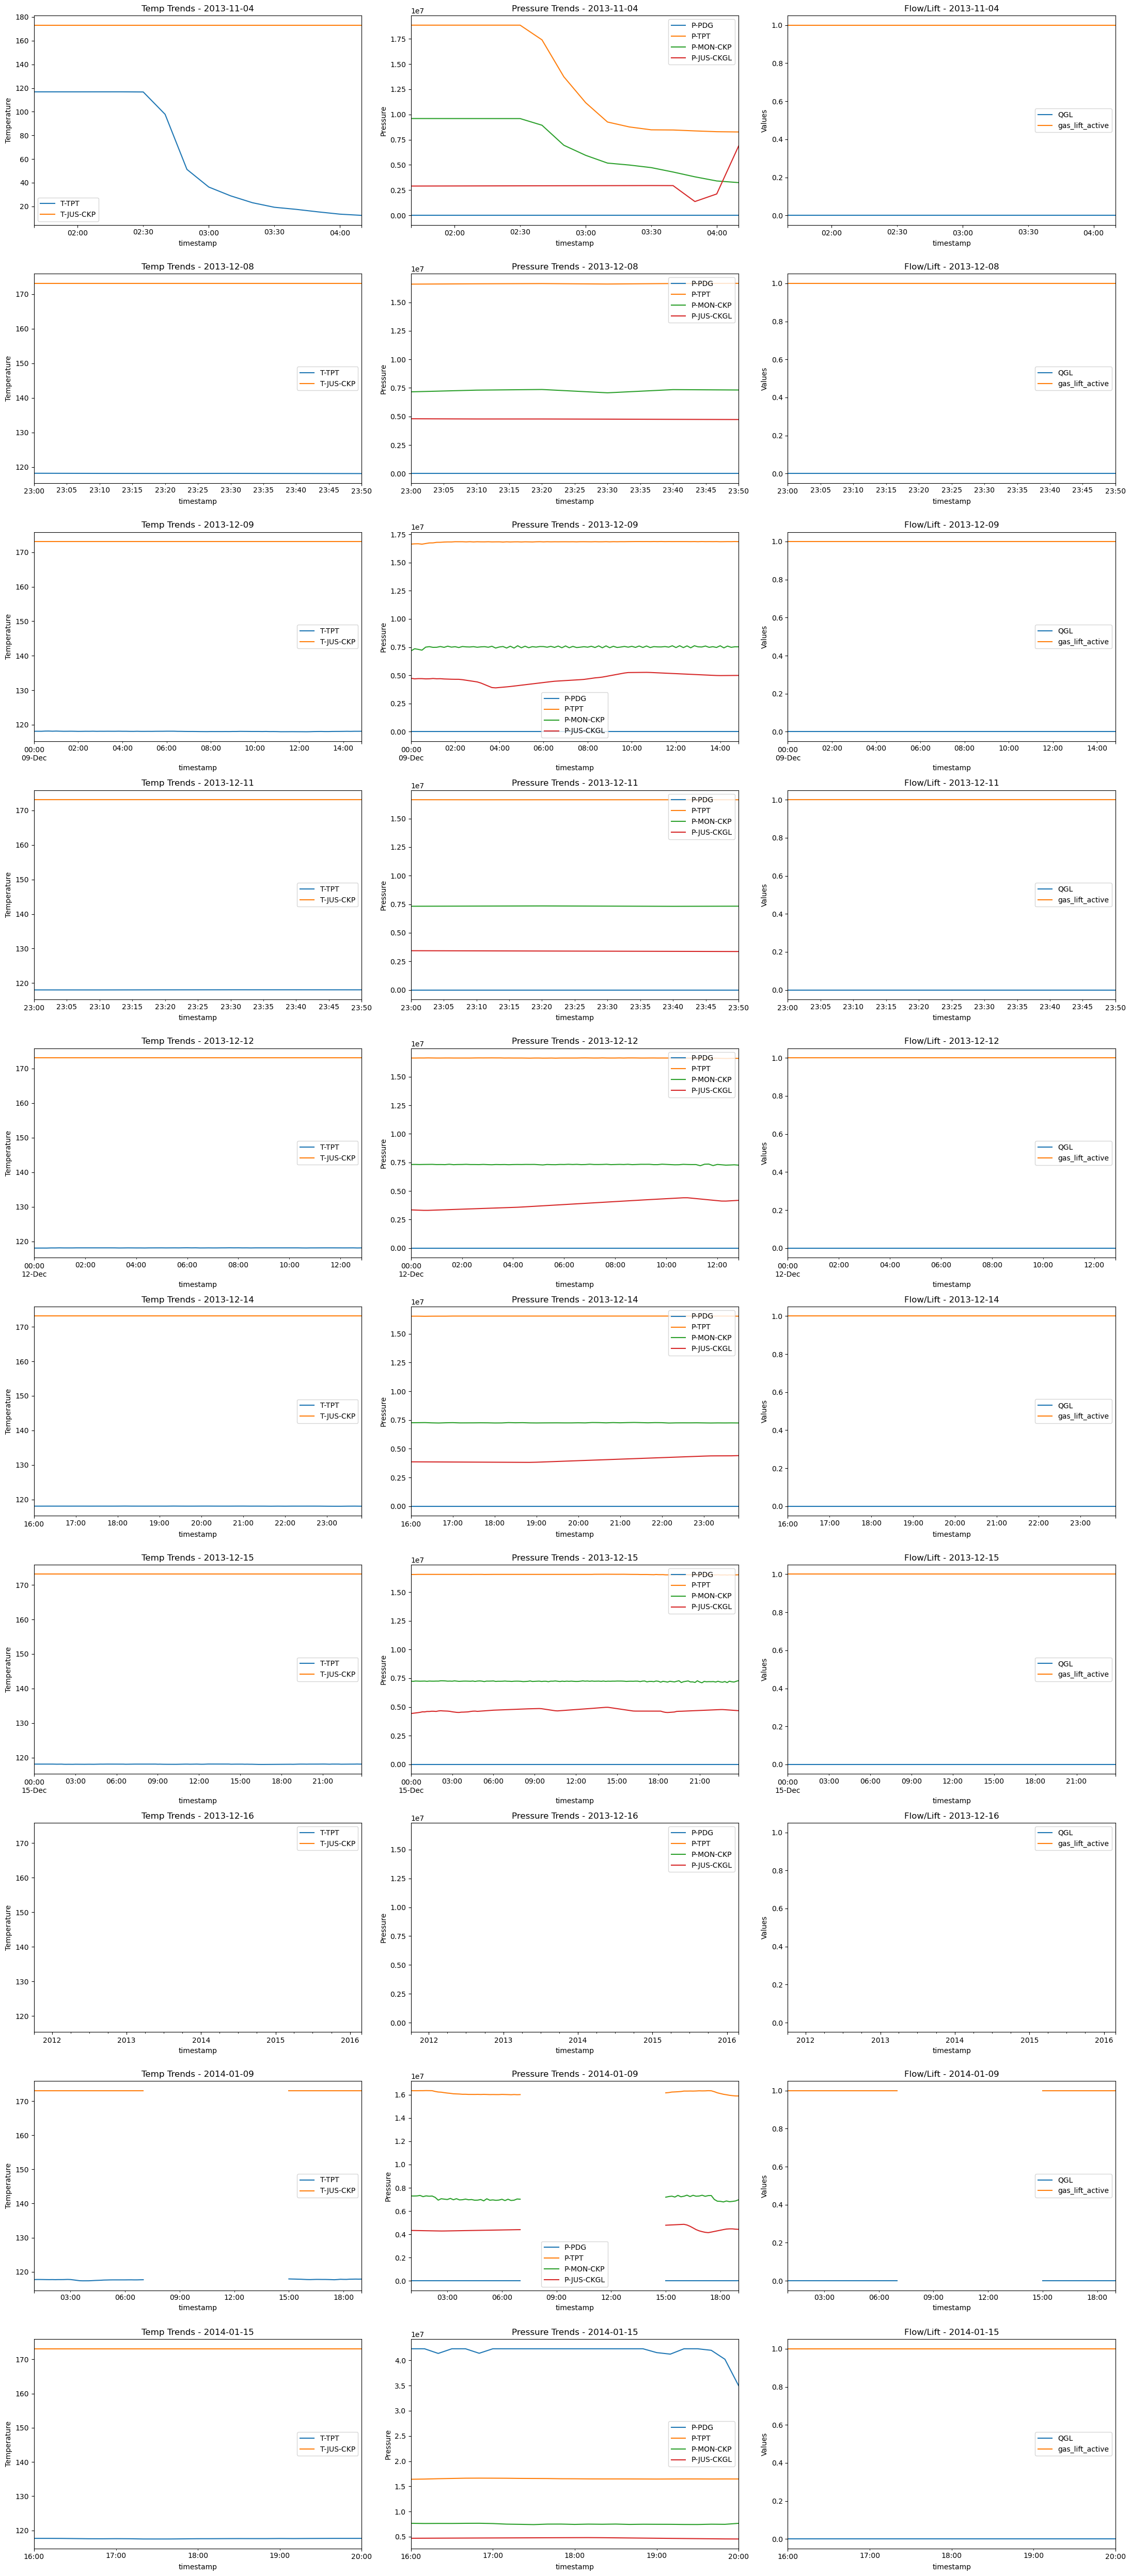

In [9]:
df = df.sort_values('timestamp')

# Column Groups
temp_cols = ['T-TPT', 'T-JUS-CKP']
press_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']
flow_cols = ['QGL', 'gas_lift_active']

# Select sample dates for visualization
unique_dates = df['timestamp'].dt.date.unique()
sample_dates = unique_dates[:10]  # Example: first 3 unique days

fig, axes = plt.subplots(nrows=len(sample_dates), ncols=3, figsize=(22, 5 * len(sample_dates)))

for i, date in enumerate(sample_dates):
    day_data = df[df['timestamp'].dt.date == date]
    # Resample to 10-minute mean trend
    day_resampled = day_data.set_index('timestamp').resample('10min').mean()
    
    # Temperature Plot
    day_resampled[temp_cols].plot(ax=axes[i, 0], title=f"Temp Trends - {date}")
    axes[i, 0].set_ylabel("Temperature")
    
    # Pressure Plot
    day_resampled[press_cols].plot(ax=axes[i, 1], title=f"Pressure Trends - {date}")
    axes[i, 1].set_ylabel("Pressure")
    
    # Flow/Lift Plot
    day_resampled[flow_cols].plot(ax=axes[i, 2], title=f"Flow/Lift - {date}")
    axes[i, 2].set_ylabel("Values")

plt.tight_layout()
plt.show()

<h1>1-hour Temporal Trends per Day</h1>
By resampling the data to 1hr intervals, we smooth out high-frequency noise and focus on the overall movement of temperatures and pressures across different days. The subplots below show the grouped sensors (Temp, Pressure, and Flow) for specific dates.

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Use

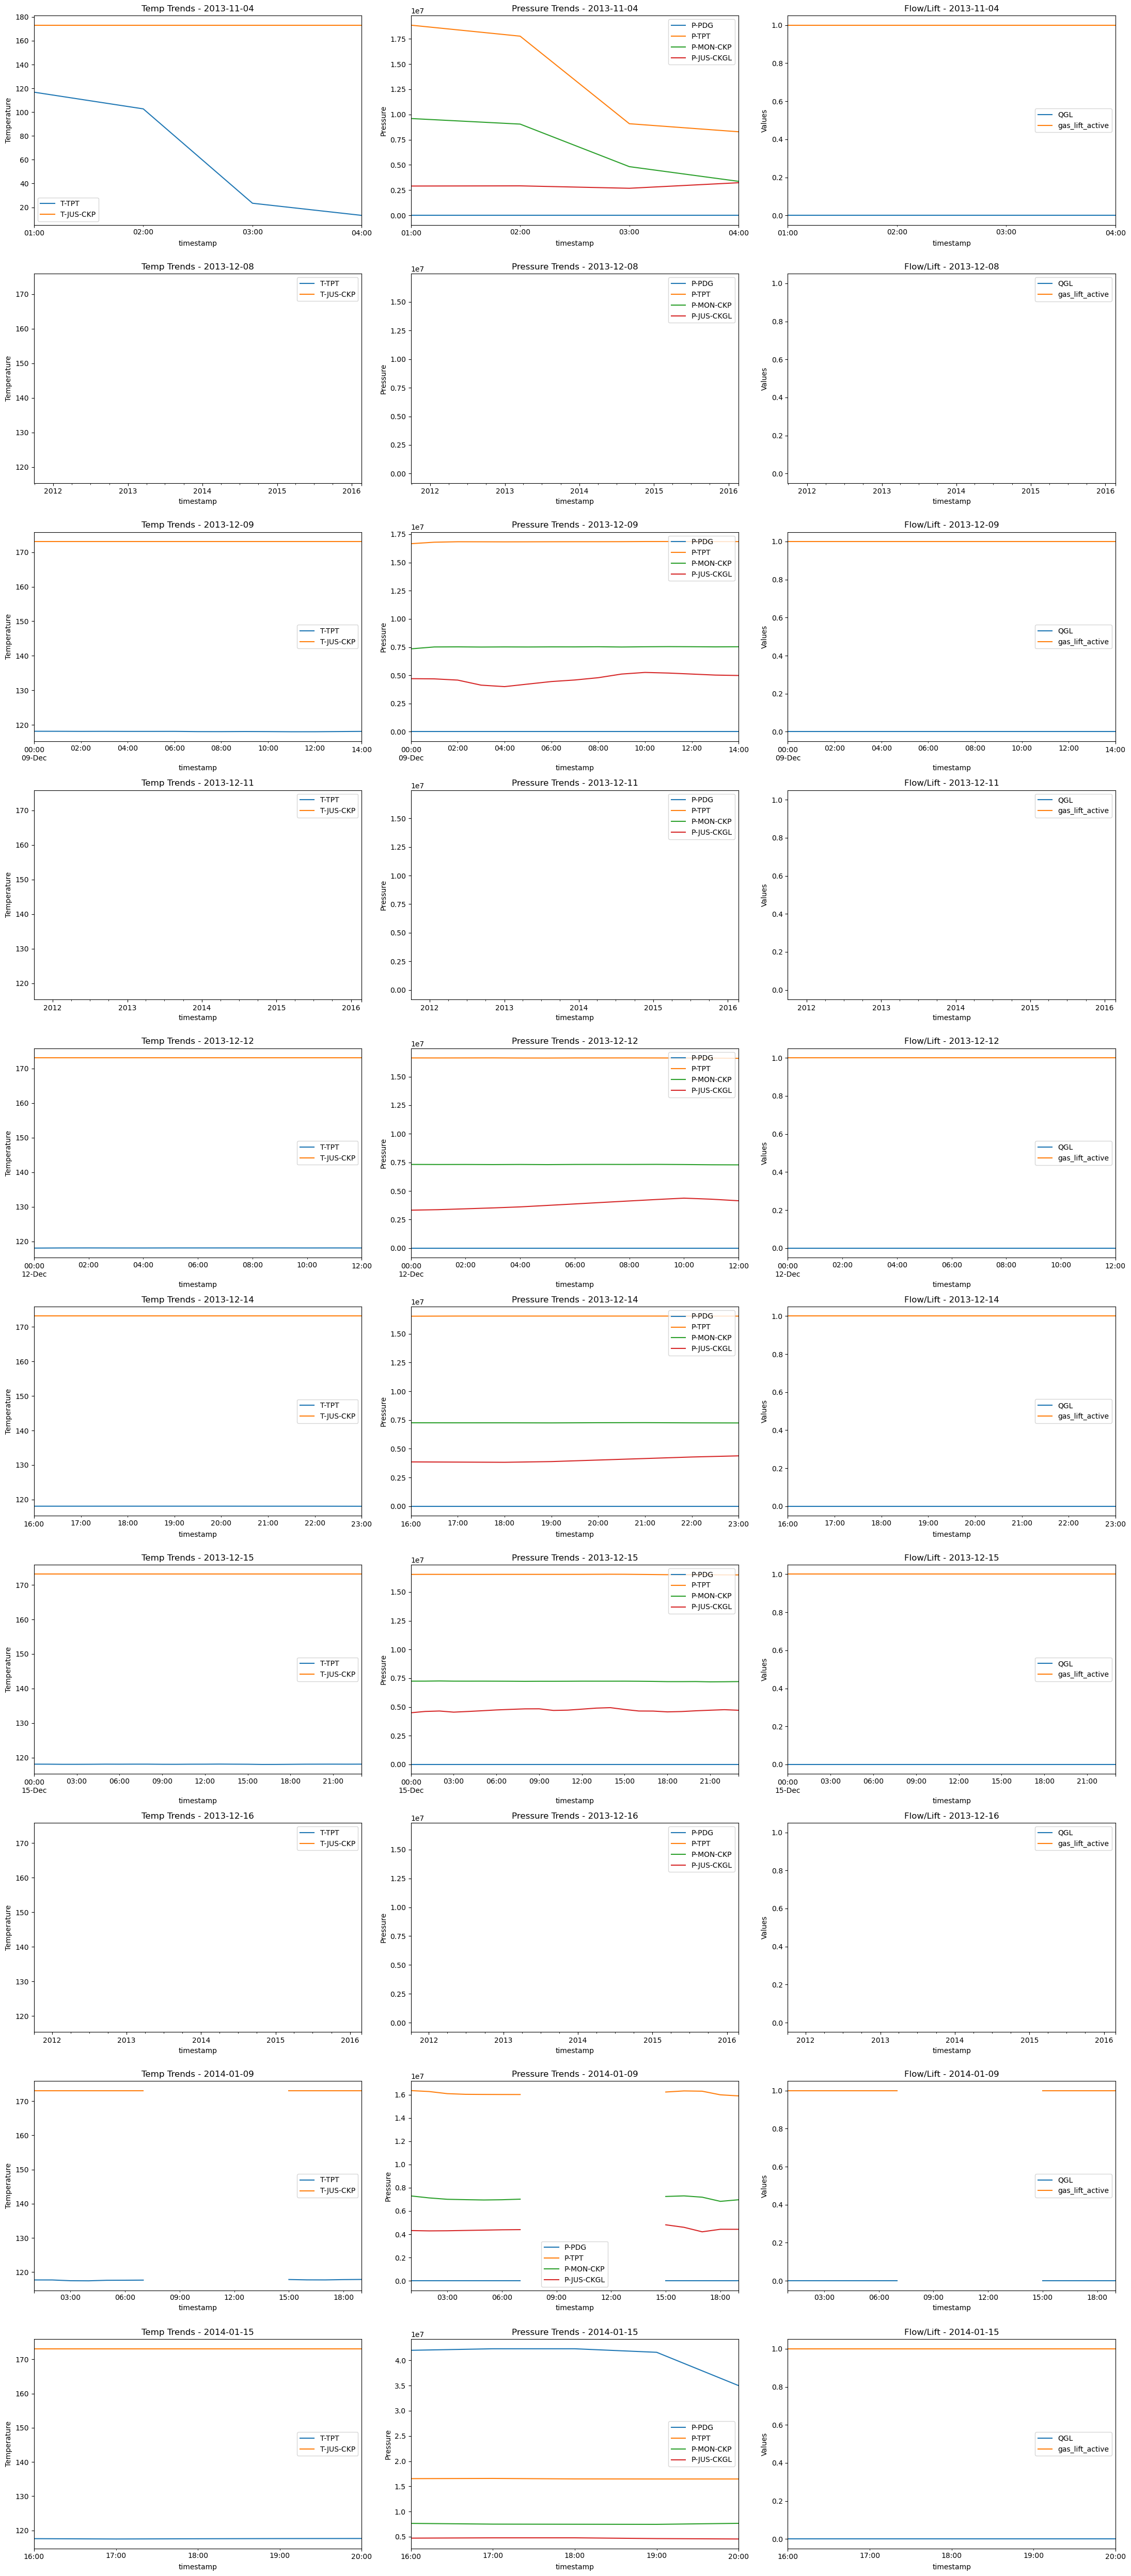

In [12]:
df = df.sort_values('timestamp')

# Column Groups
temp_cols = ['T-TPT', 'T-JUS-CKP']
press_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']
flow_cols = ['QGL', 'gas_lift_active']

# Select sample dates for visualization
unique_dates = df['timestamp'].dt.date.unique()
sample_dates = unique_dates[:10]  # Example: first 3 unique days

fig, axes = plt.subplots(nrows=len(sample_dates), ncols=3, figsize=(22, 5 * len(sample_dates)))

for i, date in enumerate(sample_dates):
    day_data = df[df['timestamp'].dt.date == date]
    # Resample to 1-HOUR mean trend
    day_resampled = day_data.set_index('timestamp').resample('1h').mean()
    
    # Temperature Plot
    day_resampled[temp_cols].plot(ax=axes[i, 0], title=f"Temp Trends - {date}")
    axes[i, 0].set_ylabel("Temperature")
    
    # Pressure Plot
    day_resampled[press_cols].plot(ax=axes[i, 1], title=f"Pressure Trends - {date}")
    axes[i, 1].set_ylabel("Pressure")
    
    # Flow/Lift Plot
    day_resampled[flow_cols].plot(ax=axes[i, 2], title=f"Flow/Lift - {date}")
    axes[i, 2].set_ylabel("Values")

plt.tight_layout()
plt.show()

<h1>2. Clustering and Class Distribution (Scatter & KDE)</h1>
The scatter plots help us see how different fault classes occupy specific "regions" in the sensor space. The KDE plots are specifically designed to show the transition: we plot the Normal state (0), the Transient state (e.g., 101), and the Fault state (e.g., 1) together to see how the distribution shifts as the fault develops.

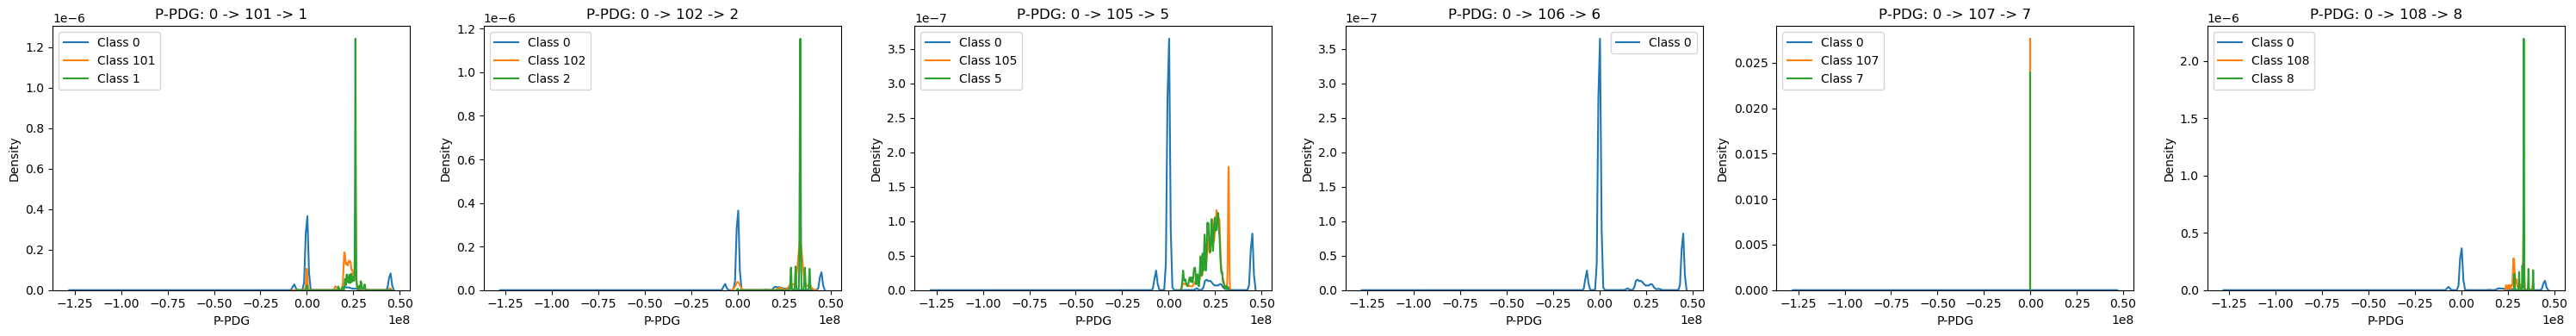

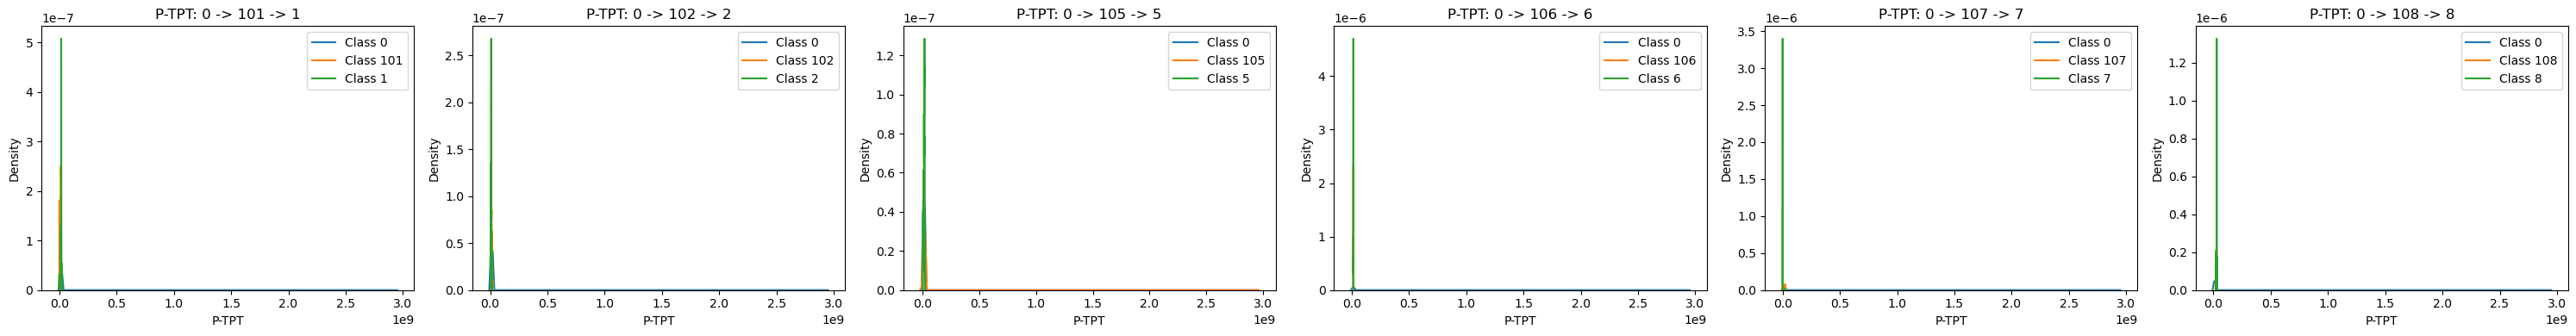

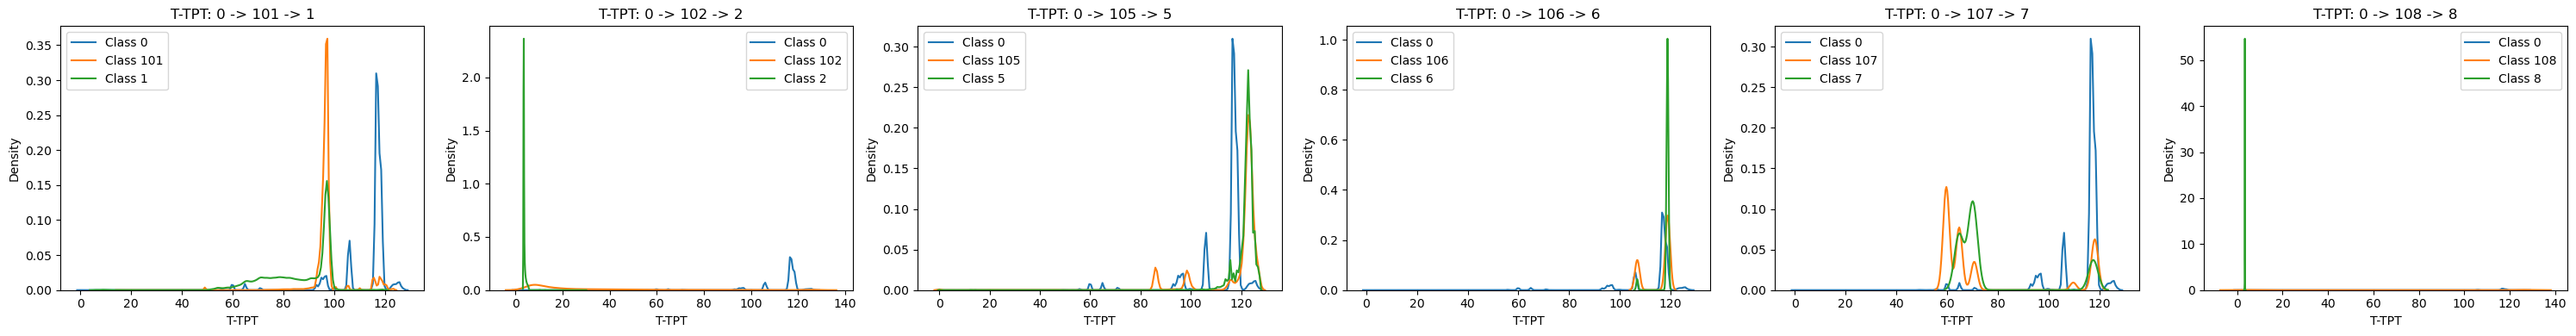

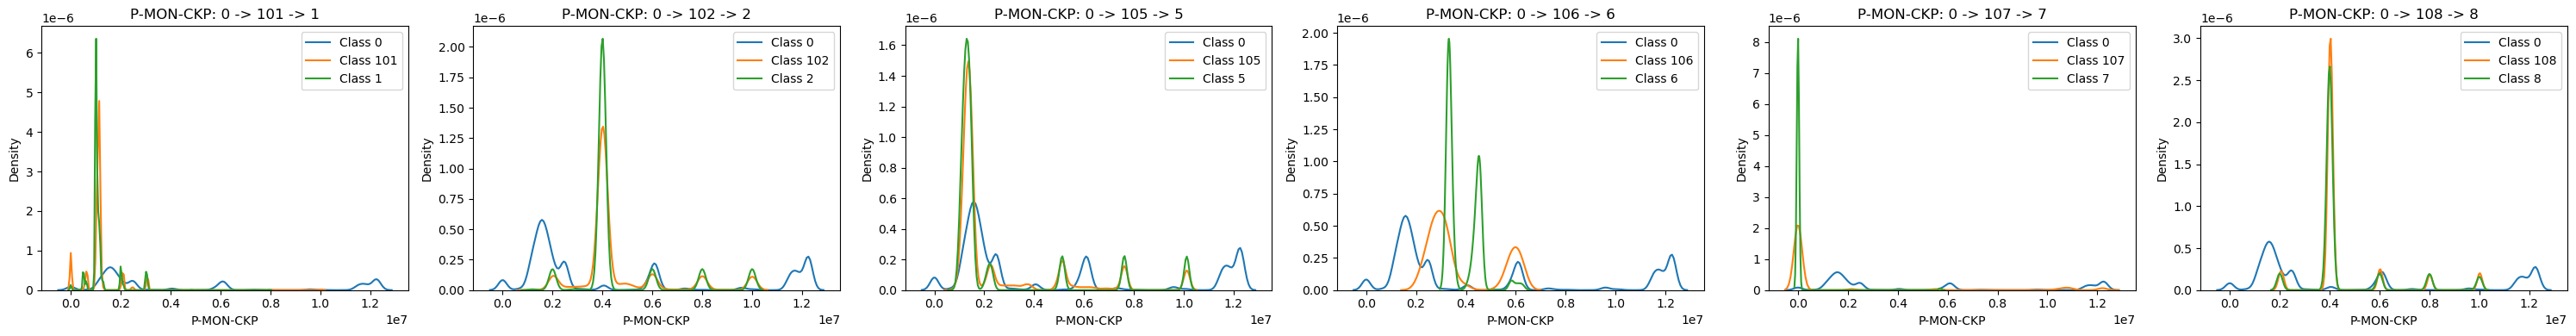

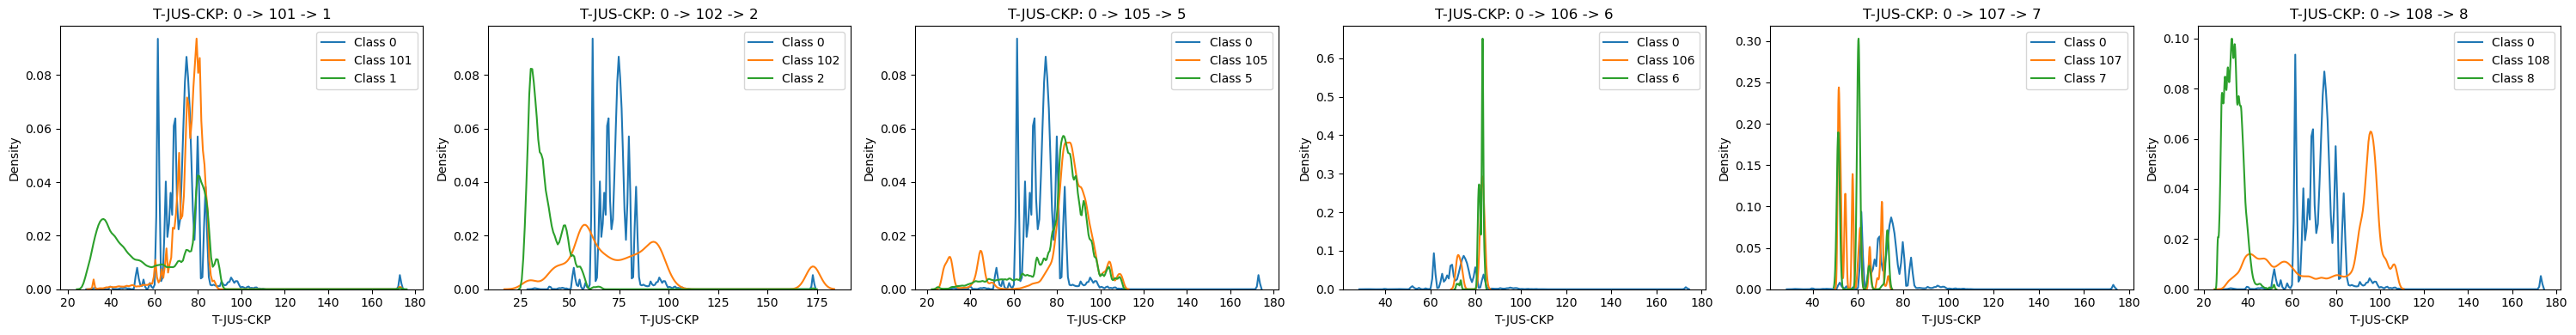

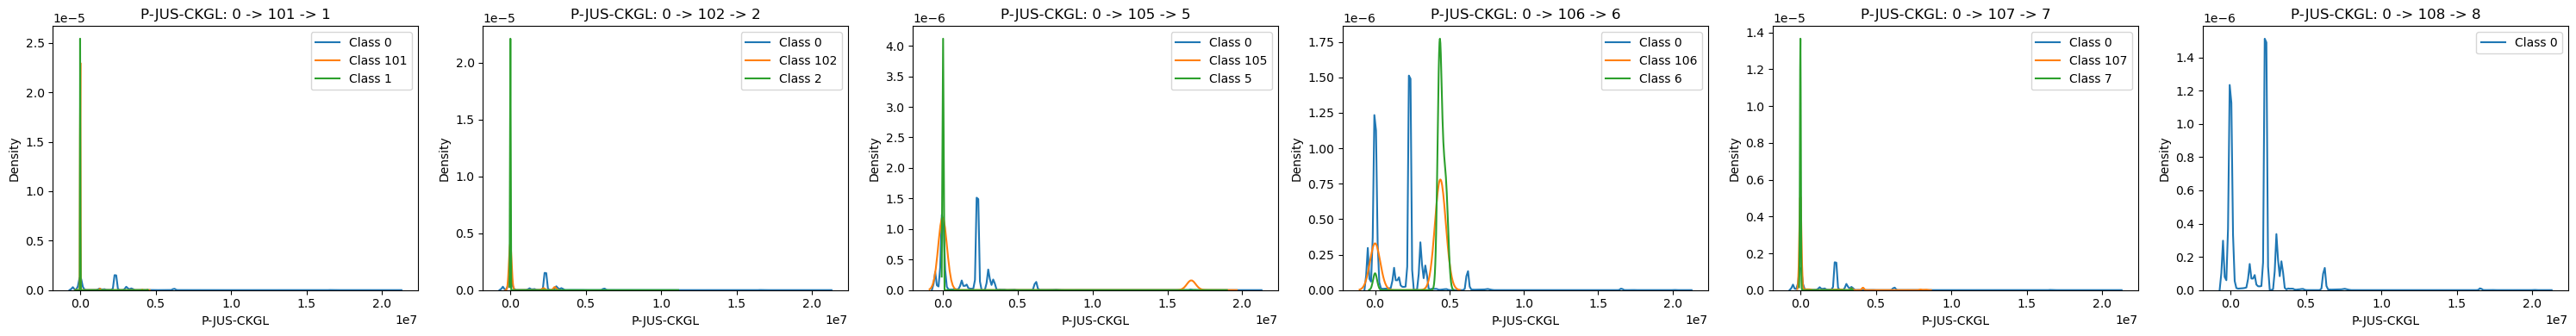

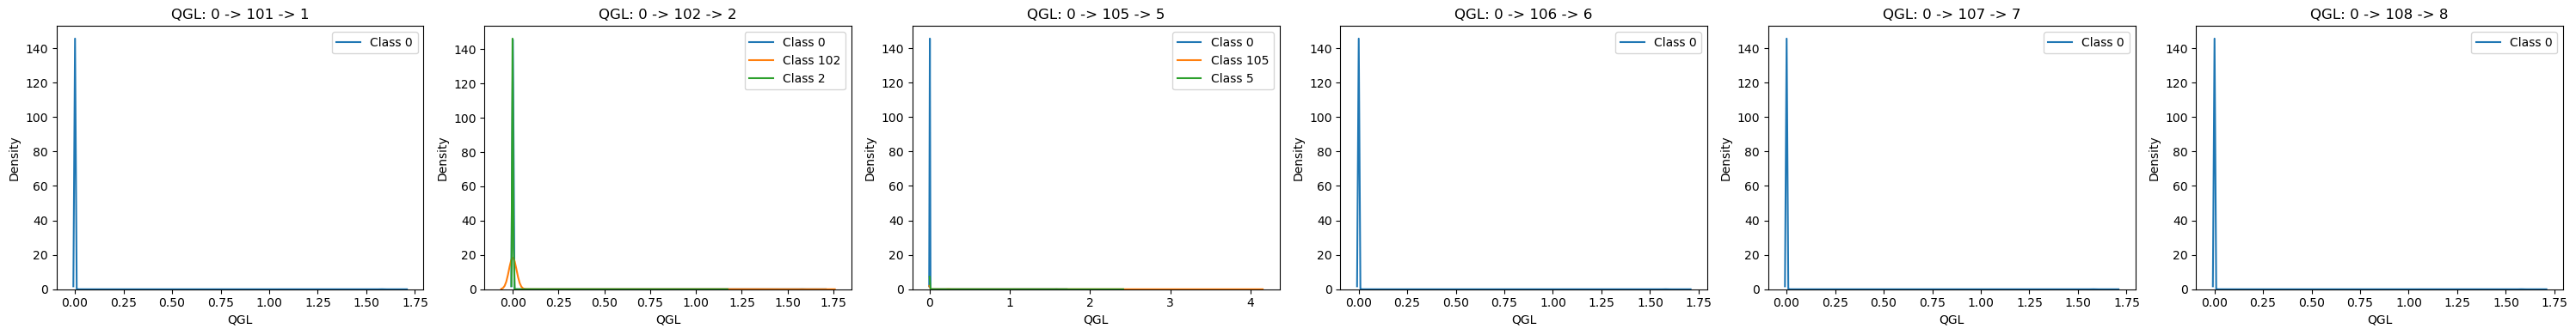

/var/folders/0d/98yx7vws6z7by9wbrr_wprbc0000gp/T/ipykernel_50668/1546539101.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/0d/98yx7vws6z7by9wbrr_wprbc0000gp/T/ipykernel_50668/1546539101.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/0d/98yx7vws6z7by9wbrr_wprbc0000gp/T/ipykernel_50668/1546539101.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/var/folders/0d/98yx7vws6z7by9wbrr_wprbc0000gp/T/ipykernel_50668/1546539101.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore 

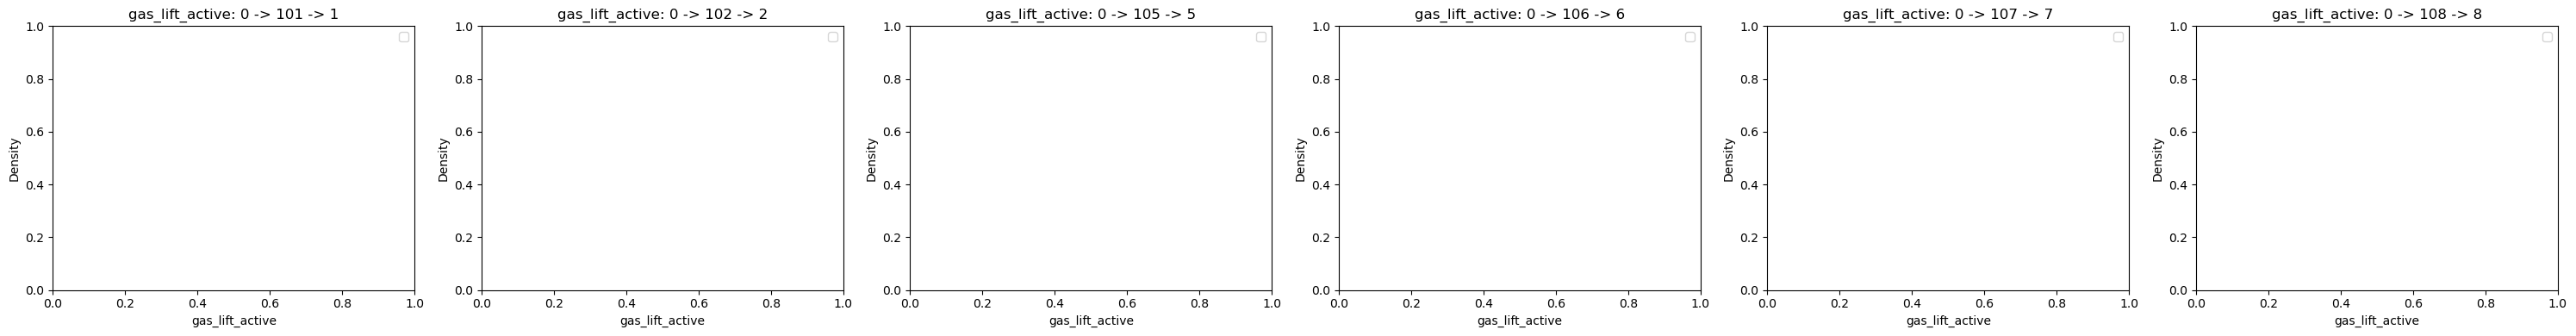

In [6]:
import seaborn as sns
# 1. Define Sensors and Detect Fault Families
columns = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL', 'gas_lift_active']
unique_classes = sorted(df['class'].unique())
fault_families = [(int(f), int(100 + f)) for f in unique_classes if 0 < f < 100 and (100 + f) in unique_classes]

# 2. Generate KDE plots per column
for col in columns:
    n_families = len(fault_families)
    fig, axes = plt.subplots(1, n_families, figsize=(5 * n_families, 4))
    
    # Ensure axes is iterable even if there's only one family
    if n_families == 1: axes = [axes]
    
    for idx, (fault, transient) in enumerate(fault_families):
        subset = df[df['class'].isin([0, fault, transient])]
        ax = axes[idx]
        
        # Plot Normal (0), then the Transient, then the Fault
        for c in [0, transient, fault]:
            sns.kdeplot(data=subset[subset['class'] == c], x=col, ax=ax, 
                        label=f'Class {int(c)}', warn_singular=False)
        
        ax.set_title(f"{col}: 0 -> {transient} -> {fault}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

<h1>Histogram plots</h1>

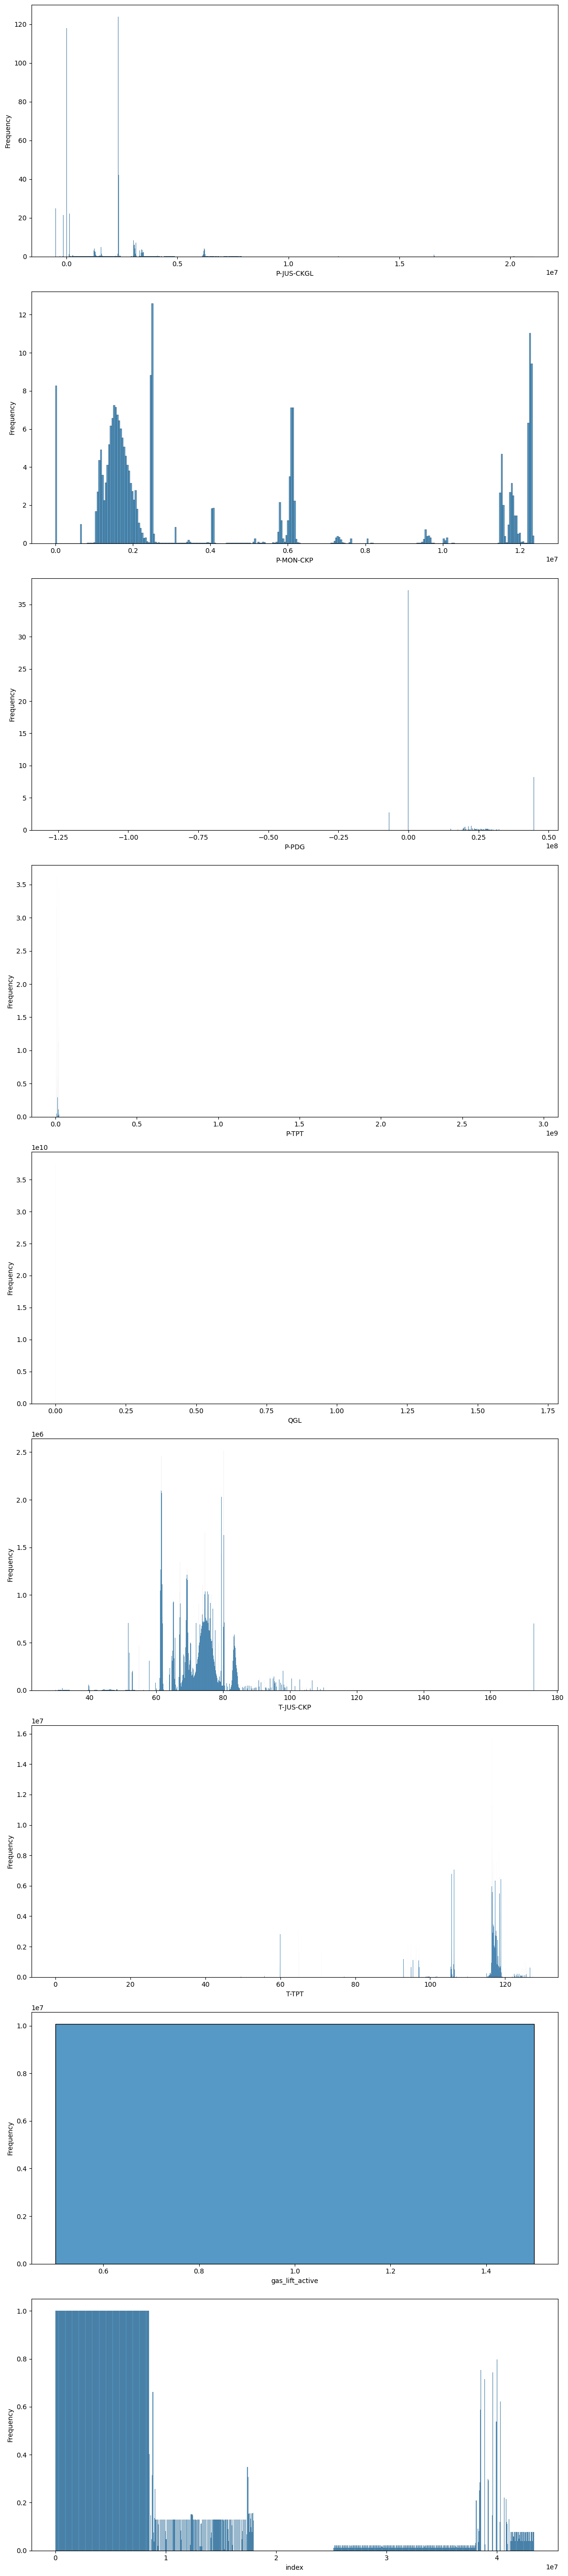

In [6]:
plot_df = df.reset_index()

not_in = ['class','P-PDG_is_missing', 'timestamp']

cols_to_plot = plot_df.columns.difference(not_in)

n_cols = len(cols_to_plot)
fig, ax = plt.subplots(n_cols,1, figsize= (12, 6 * n_cols))

class_zero_df = plot_df.loc[plot_df["class"] == 0]

for i, cols in enumerate(cols_to_plot):
    sns.histplot(data=class_zero_df, x=cols, stat="frequency", ax=ax[i])

plt.tight_layout()
plt.show()
    

<h1>Box-Plot</h1>

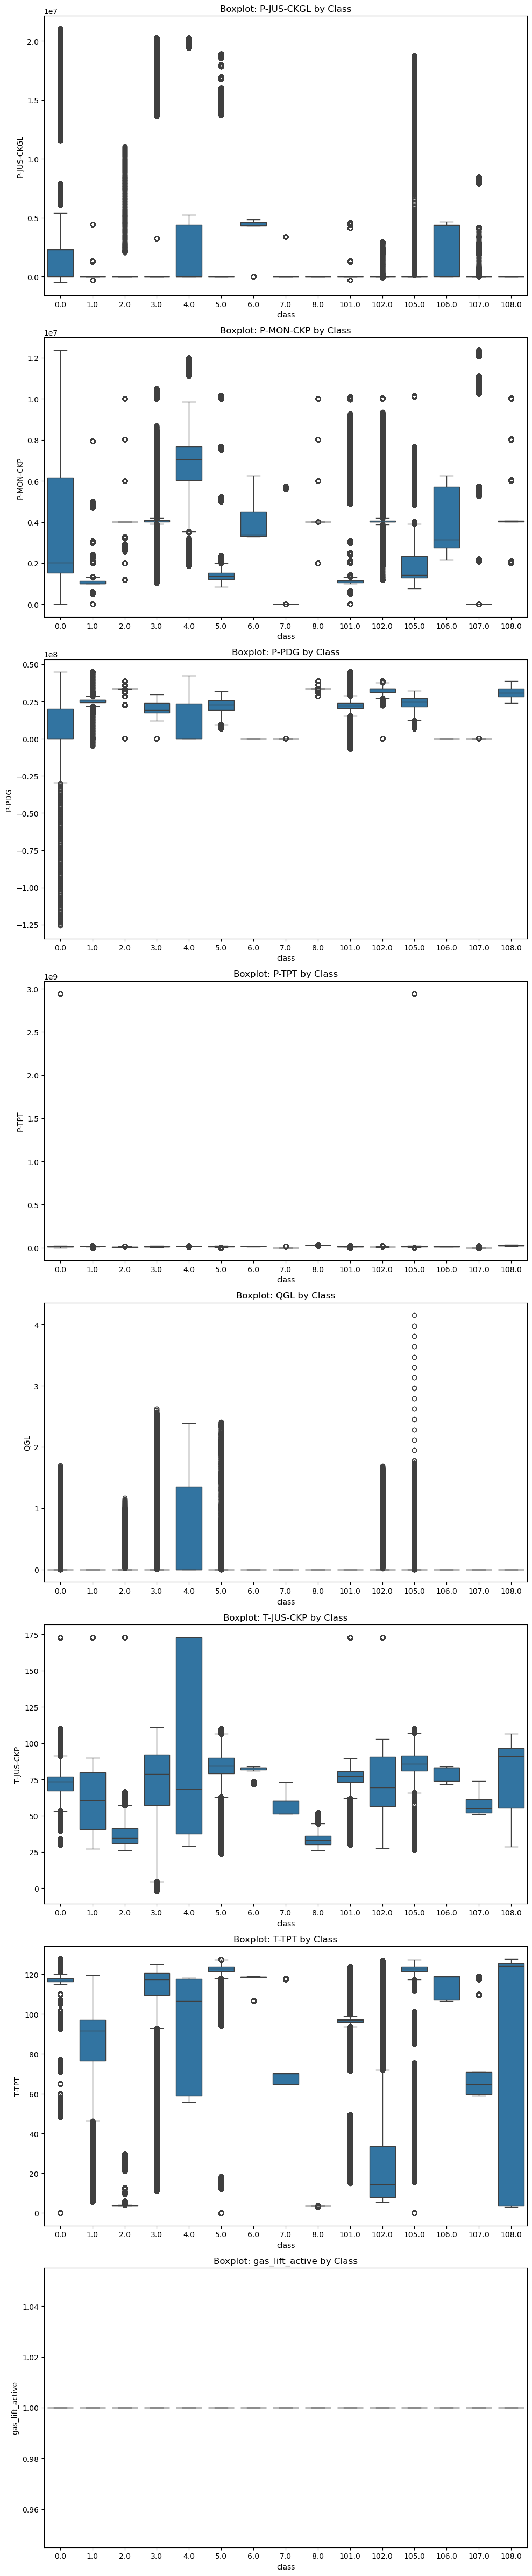

In [15]:
not_in = ['class','P-PDG_is_missing', 'timestamp', 'index']
cols_to_plot = plot_df.columns.difference(not_in)
n_rows = len(cols_to_plot) # One row per feature. this boxplot contains all the classes.

fig, ax = plt.subplots(n_rows, 1, figsize=(10,6 * n_rows))
for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=plot_df, x="class", y=col, ax=ax[i])
    ax[i].set_title(f"Boxplot: {col} by Class")

plt.tight_layout()
plt.show()